In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_7 = pd.read_csv("df_7.csv")

date_cols = ["review_date", "order_date", "ship_date", "delivery_date"]

for col in date_cols:
    df_7[col] = pd.to_datetime(df_7[col], errors="coerce")

# Delivery time
df_7["ship_delay_days"] = (df_7["ship_date"] - df_7["order_date"]).dt.days
df_7["delivery_days"] = (df_7["delivery_date"] - df_7["order_date"]).dt.days
df_7["shipping_duration_days"] = (df_7["delivery_date"] - df_7["ship_date"]).dt.days

# Review delay: khách review sau bao lâu kể từ khi nhận hàng
df_7["review_delay_days"] = (df_7["review_date"] - df_7["delivery_date"]).dt.days

# Low rating flag
df_7["low_rating"] = (df_7["rating"] <= 3).astype(int)
df_7["high_rating"] = (df_7["rating"] >= 4).astype(int)

# Price and margin
df_7["profit_margin"] = df_7["price"] - df_7["cogs"]
df_7["margin_rate"] = df_7["profit_margin"] / df_7["price"]

# Price tier
df_7["price_tier"] = pd.qcut(
    df_7["price"],
    q=4,
    labels=["Low price", "Mid-low price", "Mid-high price", "High price"],
    duplicates="drop"
)

# Delivery speed group
df_7["delivery_speed"] = pd.cut(
    df_7["delivery_days"],
    bins=[-1, 3, 5, 7, np.inf],
    labels=["Fast: 0-3 days", "Normal: 4-5 days", "Slow: 6-7 days", "Very slow: 8+ days"]
)

# Check
df_7[[
    "review_id", "order_id", "product_id", "rating",
    "delivery_days", "review_delay_days",
    "category", "segment", "price", "price_tier"
]].head()

,review_id,order_id,product_id,rating,delivery_days,review_delay_days,category,segment,price,price_tier
0,REV-0000001,1.0,2400.0,5.0,7.0,13.0,GenZ,Trendy,1109.261061,Low price
1,REV-0000002,3.0,396.0,5.0,3.0,27.0,Streetwear,Balanced,11028.428695,High price
2,REV-0000003,10.0,1431.0,5.0,7.0,10.0,Outdoor,Activewear,4093.740000,Mid-high price
3,REV-0000005,16.0,1668.0,5.0,7.0,24.0,Streetwear,Standard,5164.740000,Mid-high price
4,REV-0000006,17.0,2352.0,4.0,6.0,6.0,Streetwear,Performance,4441.323020,Mid-high price


In [2]:
rating_dist = df_7["rating"].value_counts().sort_index().reset_index()
rating_dist.columns = ["rating", "count"]
rating_dist["percentage"] = rating_dist["count"] / rating_dist["count"].sum() * 100

rating_dist

,rating,count,percentage
0,1.0,686,4.965977
1,2.0,1154,8.353844
2,3.0,1992,14.420153
3,4.0,4479,32.423628
4,5.0,5503,39.836398


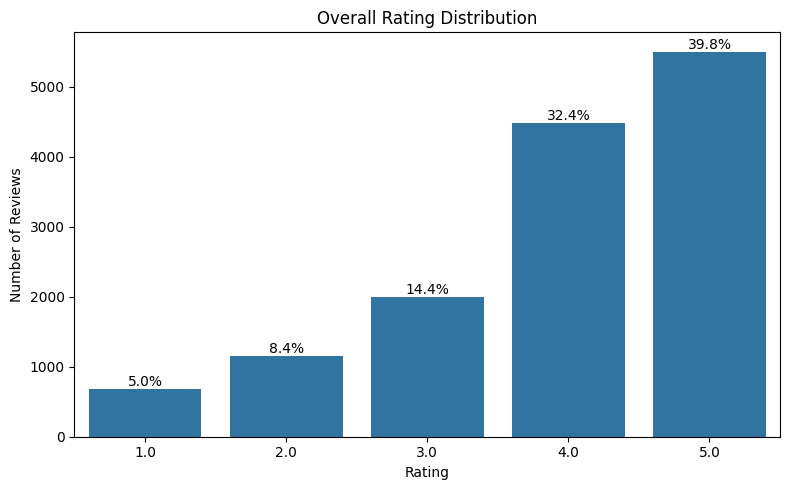

In [3]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_dist,
    x="rating",
    y="count"
)

plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, row in rating_dist.iterrows():
    plt.text(
        i,
        row["count"],
        f"{row['percentage']:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [4]:
delivery_rating = df_7.groupby("delivery_days").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

# Loại các nhóm quá ít review để tránh nhiễu
delivery_rating = delivery_rating[delivery_rating["num_reviews"] >= 30]

delivery_rating

,delivery_days,avg_rating,low_rating_rate,num_reviews
0,2.0,4.030909,0.252727,550
1,3.0,3.991554,0.249155,1184
2,4.0,3.915293,0.282547,1759
3,5.0,3.926386,0.286918,2255
4,6.0,3.929620,0.284974,2316
5,7.0,3.903993,0.287171,2354
6,8.0,3.972339,0.266987,1663
7,9.0,3.966754,0.250219,1143
8,10.0,3.874576,0.318644,590


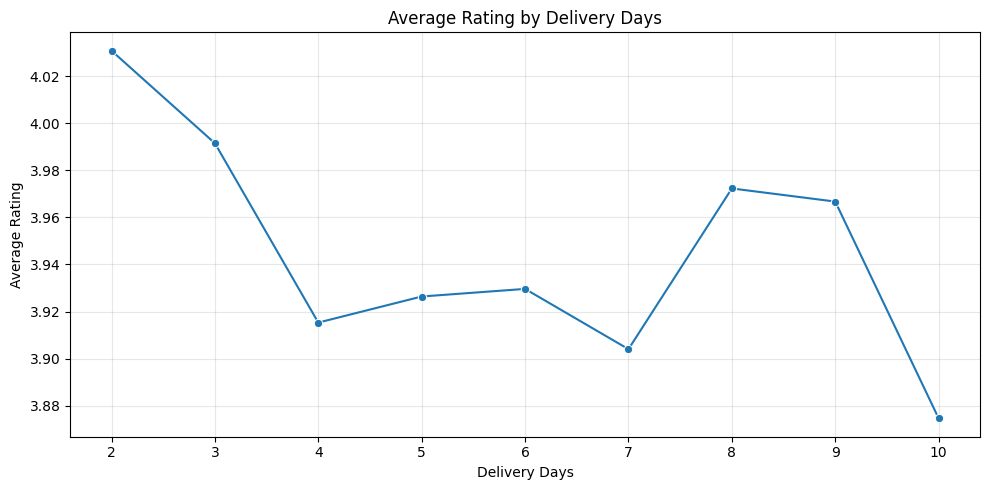

In [5]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=delivery_rating,
    x="delivery_days",
    y="avg_rating",
    marker="o"
)

plt.title("Average Rating by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
corr_delivery_rating = df_7[["delivery_days", "rating"]].corr().iloc[0, 1]
corr_delivery_low = df_7[["delivery_days", "low_rating"]].corr().iloc[0, 1]

print(f"Correlation between delivery days and rating: {corr_delivery_rating:.4f}")
print(f"Correlation between delivery days and low rating risk: {corr_delivery_low:.4f}")

Correlation between delivery days and rating: -0.0094
Correlation between delivery days and low rating risk: 0.0085


In [7]:
delivery_speed_perf = df_7.groupby("delivery_speed", observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

delivery_speed_perf["low_rating_rate_pct"] = delivery_speed_perf["low_rating_rate"] * 100

delivery_speed_perf

,delivery_speed,avg_rating,low_rating_rate,num_reviews,low_rating_rate_pct
0,Fast: 0-3 days,4.004037,0.250288,1734,25.028835
1,Normal: 4-5 days,3.921525,0.285002,4014,28.500249
2,Slow: 6-7 days,3.916702,0.286081,4670,28.608137
3,Very slow: 8+ days,3.953475,0.270318,3396,27.031802


In [8]:
category_rating = df_7.groupby("category").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

category_rating["low_rating_rate_pct"] = category_rating["low_rating_rate"] * 100

category_rating = category_rating.sort_values("avg_rating")

category_rating

,category,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,low_rating_rate_pct
2,Outdoor,3.920180,0.285338,6452,5.978921,1913.987630,28.533788
3,Streetwear,3.943456,0.272686,6579,6.006232,7574.095056,27.268582
0,Casual,3.996296,0.266667,270,5.922222,4232.397398,26.666667
1,GenZ,4.064327,0.243665,513,6.116959,1745.076185,24.366472


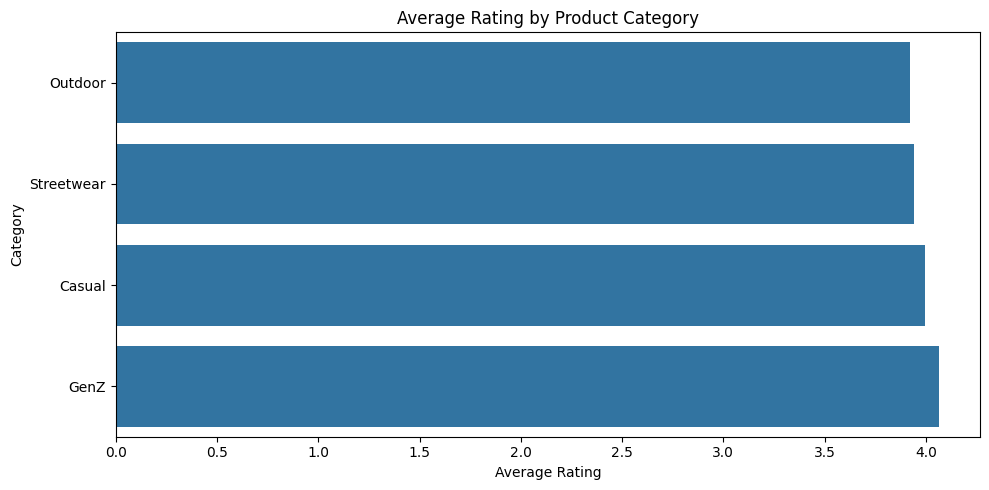

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_rating,
    x="avg_rating",
    y="category"
)

plt.title("Average Rating by Product Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [10]:
segment_rating = df_7.groupby("segment").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

segment_rating["low_rating_rate_pct"] = segment_rating["low_rating_rate"] * 100
segment_rating = segment_rating.sort_values("avg_rating")

segment_rating

,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,low_rating_rate_pct
4,Performance,3.900690,0.284138,1450,6.057241,5867.592492,28.413793
0,Activewear,3.913463,0.288054,5801,5.986726,1768.692690,28.805378
3,Everyday,3.950893,0.271763,3584,5.965402,7013.286662,27.176339
2,Balanced,3.956160,0.264550,1323,6.040816,11464.665478,26.455026
5,Premium,3.980031,0.261137,651,5.909370,3208.697220,26.113671
1,All-weather,3.996296,0.266667,270,5.922222,4232.397398,26.666667
6,Standard,4.027027,0.261261,222,6.126126,4588.245197,26.126126
7,Trendy,4.064327,0.243665,513,6.116959,1745.076185,24.366472


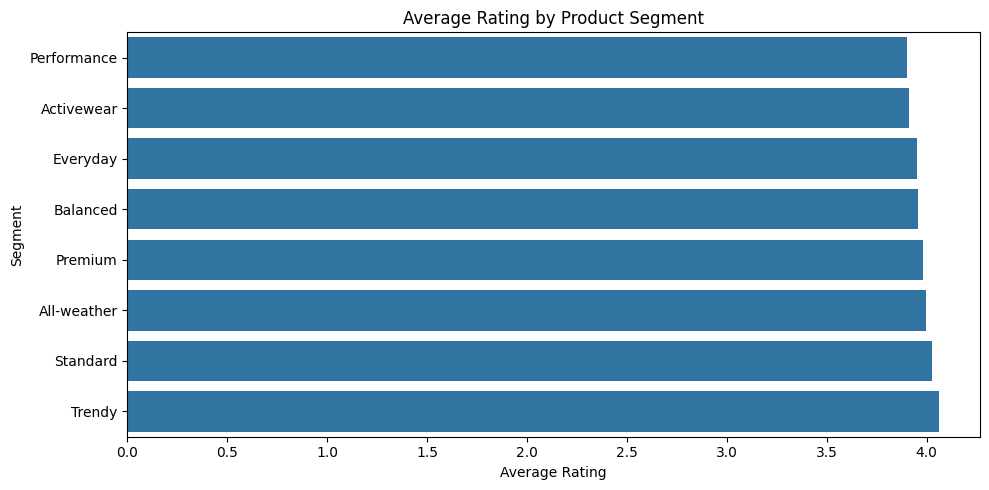

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_rating,
    x="avg_rating",
    y="segment"
)

plt.title("Average Rating by Product Segment")
plt.xlabel("Average Rating")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

In [12]:
source_rating = df_7.groupby("order_source").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

source_rating["low_rating_rate_pct"] = source_rating["low_rating_rate"] * 100
source_rating = source_rating.sort_values("avg_rating")

source_rating

,order_source,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
5,social_media,3.929985,0.280061,2628,5.969559,28.006088
2,organic_search,3.933214,0.282437,3923,6.017843,28.243691
4,referral,3.937951,0.272006,1386,5.978355,27.200577
1,email_campaign,3.940767,0.284553,1722,5.977352,28.455285
3,paid_search,3.943662,0.271536,3053,6.011792,27.153619
0,direct,3.955535,0.264973,1102,5.988203,26.497278


In [13]:
device_rating = df_7.groupby("device_type").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

device_rating["low_rating_rate_pct"] = device_rating["low_rating_rate"] * 100

device_rating

,device_type,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
0,desktop,3.937660,0.277148,5470,6.006399,27.714808
1,mobile,3.934004,0.278204,6258,5.990572,27.820390
2,tablet,3.951582,0.275647,2086,5.984660,27.564717


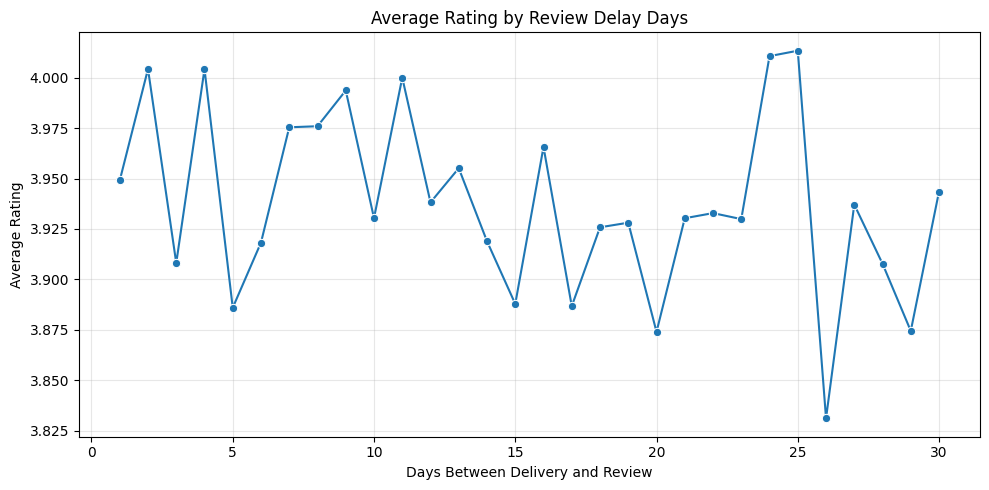

In [14]:
review_delay_rating = df_7.groupby("review_delay_days").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

review_delay_rating = review_delay_rating[
    (review_delay_rating["review_delay_days"] >= 0) &
    (review_delay_rating["num_reviews"] >= 30)
]

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=review_delay_rating,
    x="review_delay_days",
    y="avg_rating",
    marker="o"
)

plt.title("Average Rating by Review Delay Days")
plt.xlabel("Days Between Delivery and Review")
plt.ylabel("Average Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

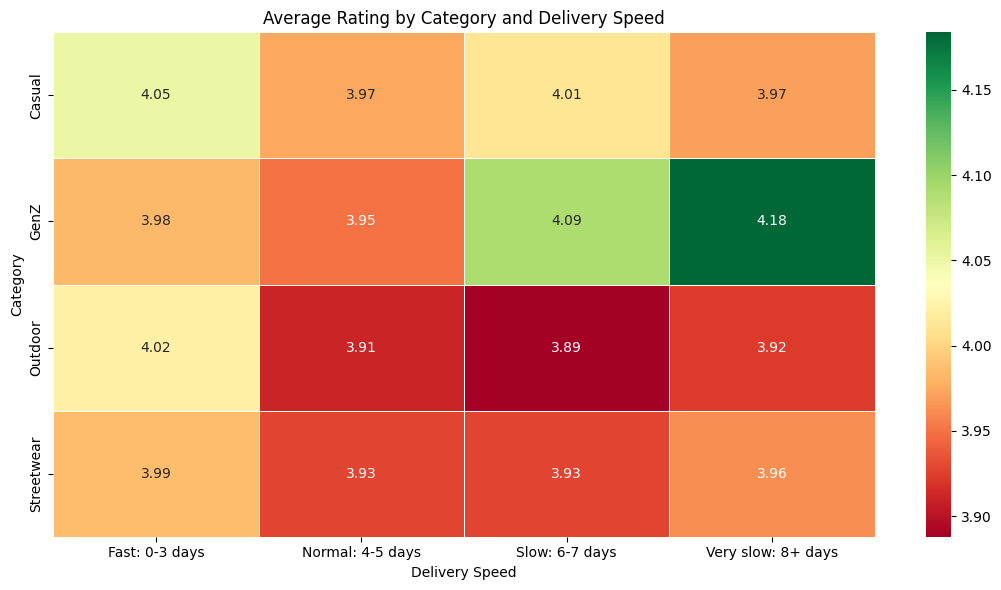

In [15]:
category_delivery = df_7.groupby(["category", "delivery_speed"], observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

category_delivery = category_delivery[category_delivery["num_reviews"] >= 30]

heatmap_avg_rating = category_delivery.pivot(
    index="category",
    columns="delivery_speed",
    values="avg_rating"
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_avg_rating,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="RdYlGn"
)

plt.title("Average Rating by Category and Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

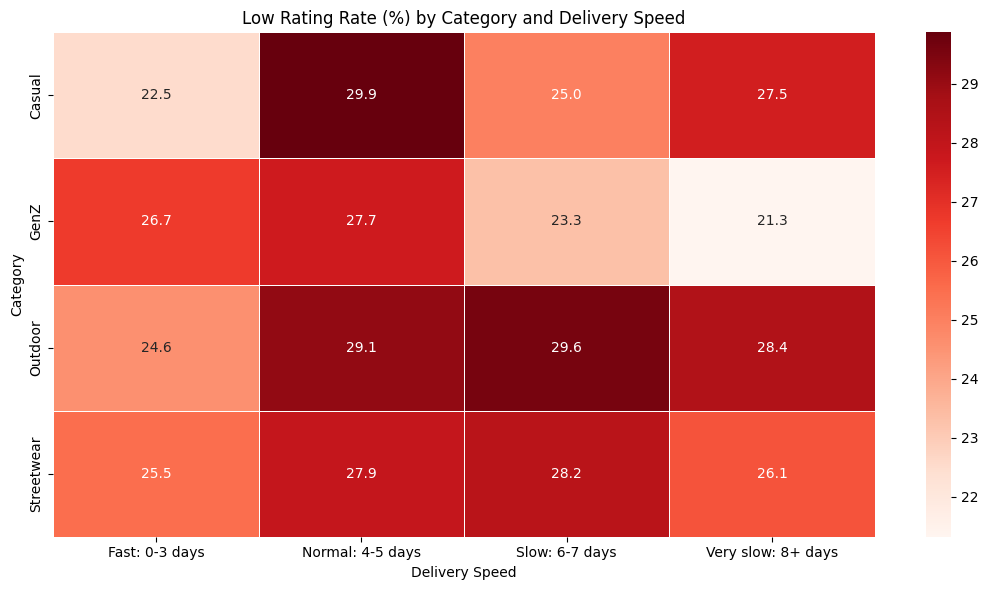

In [16]:
heatmap_low_rating = category_delivery.pivot(
    index="category",
    columns="delivery_speed",
    values="low_rating_rate"
) * 100

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_low_rating,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="Reds"
)

plt.title("Low Rating Rate (%) by Category and Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [17]:
price_rating = df_7.groupby("price_tier", observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

price_rating["low_rating_rate_pct"] = price_rating["low_rating_rate"] * 100

price_rating

,price_tier,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
0,Low price,3.930340,0.279793,3474,6.015544,27.979275
1,Mid-low price,3.930477,0.281782,3524,5.994892,28.178207
2,Mid-high price,3.957068,0.273949,3424,5.934579,27.394860
3,High price,3.934847,0.273880,3392,6.038915,27.387972


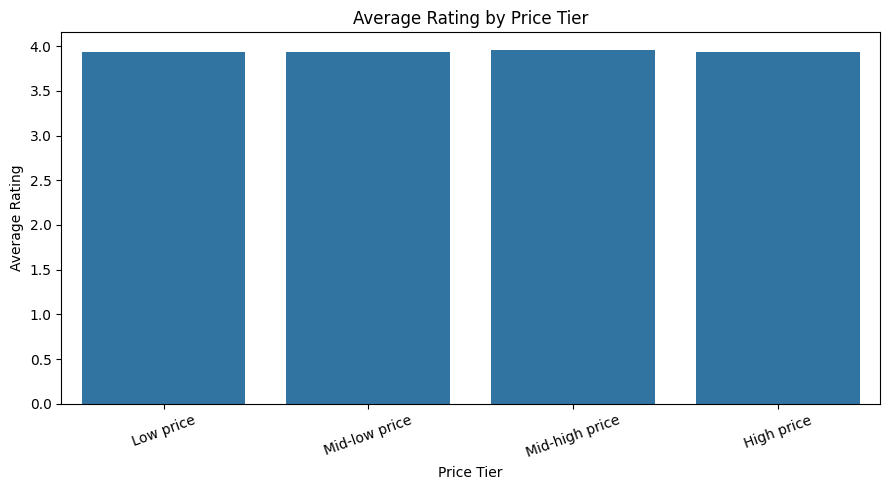

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_rating,
    x="price_tier",
    y="avg_rating"
)

plt.title("Average Rating by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Average Rating")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

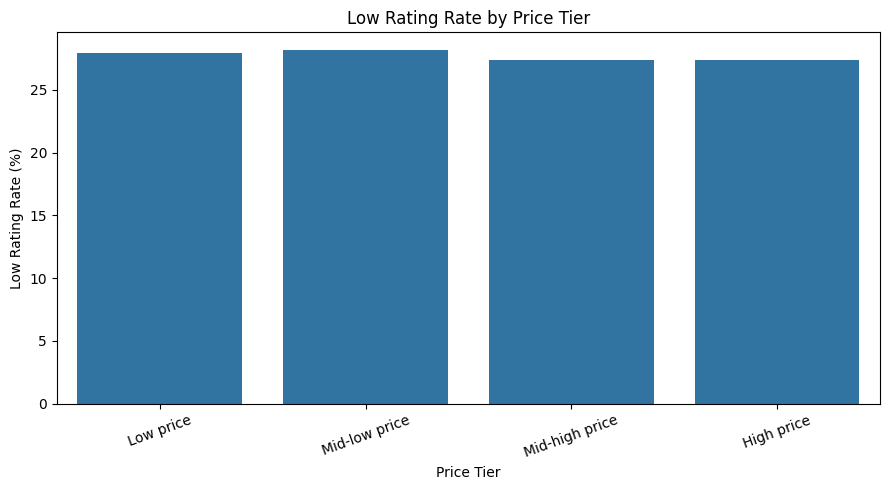

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_rating,
    x="price_tier",
    y="low_rating_rate_pct"
)

plt.title("Low Rating Rate by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Low Rating Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [20]:
product_rating = df_7.groupby([
    "product_id", "product_name", "category", "segment"
]).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

# Chỉ giữ sản phẩm có đủ review để đáng tin
product_rating = product_rating[product_rating["num_reviews"] >= 20].copy()

rating_threshold = product_rating["avg_rating"].quantile(0.25)
review_threshold = product_rating["num_reviews"].quantile(0.75)
delivery_threshold = product_rating["avg_delivery_days"].median()

def product_priority(row):
    if (row["avg_rating"] <= rating_threshold) and (row["num_reviews"] >= review_threshold):
        if row["avg_delivery_days"] >= delivery_threshold:
            return "Urgent: Low rating, high reviews, slow delivery"
        else:
            return "Product issue: Low rating, high reviews"
    elif row["avg_delivery_days"] >= delivery_threshold and row["avg_rating"] <= rating_threshold:
        return "Logistics issue: Low rating, slow delivery"
    else:
        return "Monitor"

product_rating["priority_group"] = product_rating.apply(product_priority, axis=1)

product_rating.head()

,product_id,product_name,category,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,priority_group
3,36.0,DragonWear MA-36,Casual,All-weather,4.043478,0.260870,23,6.043478,5604.936207,Monitor
9,103.0,DragonWear UM-30,Streetwear,Balanced,3.903226,0.290323,31,6.258065,10425.177091,Monitor
52,396.0,SaigonFlex UM-01,Streetwear,Balanced,4.145038,0.206107,131,6.038168,11028.428695,Monitor
53,400.0,SaigonFlex UM-05,Streetwear,Balanced,4.200000,0.160000,25,5.840000,9886.802880,Monitor
58,437.0,SaigonFlex UM-42,Streetwear,Balanced,3.807692,0.269231,26,5.500000,9651.796875,Monitor


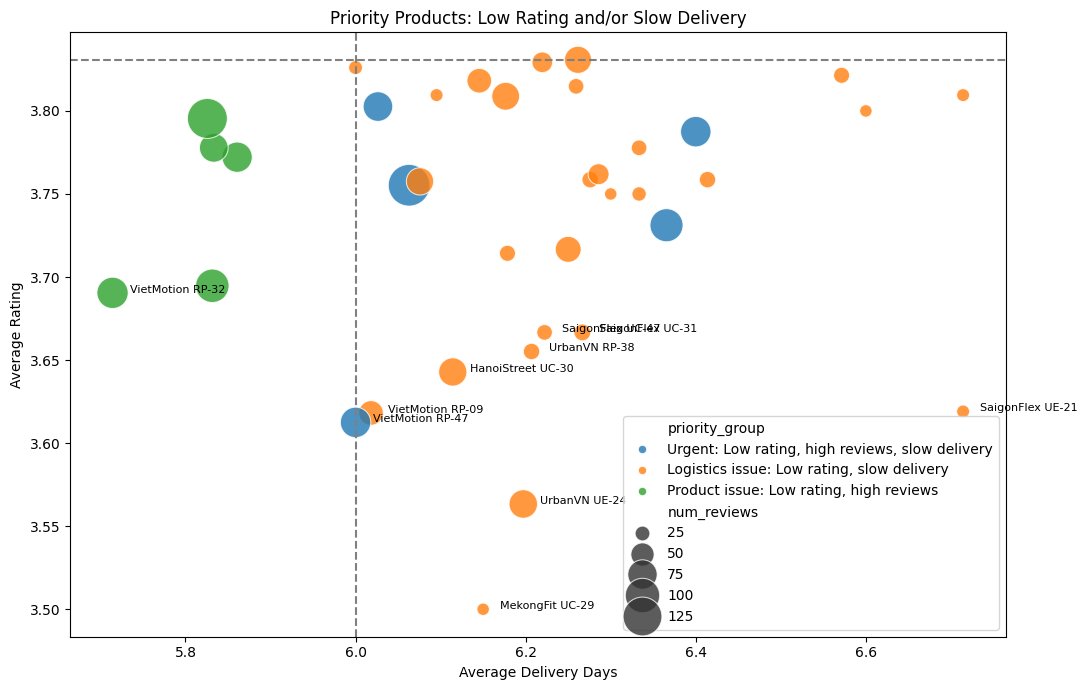

In [21]:
priority_only = product_rating[
    product_rating["priority_group"] != "Monitor"
].copy()

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=priority_only,
    x="avg_delivery_days",
    y="avg_rating",
    size="num_reviews",
    hue="priority_group",
    sizes=(80, 900),
    alpha=0.8
)

plt.axhline(rating_threshold, linestyle="--", color="gray")
plt.axvline(delivery_threshold, linestyle="--", color="gray")

plt.title("Priority Products: Low Rating and/or Slow Delivery")
plt.xlabel("Average Delivery Days")
plt.ylabel("Average Rating")

# Label top products by lowest rating or highest review volume
top_label = priority_only.sort_values(
    ["avg_rating", "num_reviews"],
    ascending=[True, False]
).head(10)

for _, row in top_label.iterrows():
    plt.text(
        row["avg_delivery_days"] + 0.02,
        row["avg_rating"],
        row["product_name"],
        fontsize=8
    )

plt.tight_layout()
plt.show()

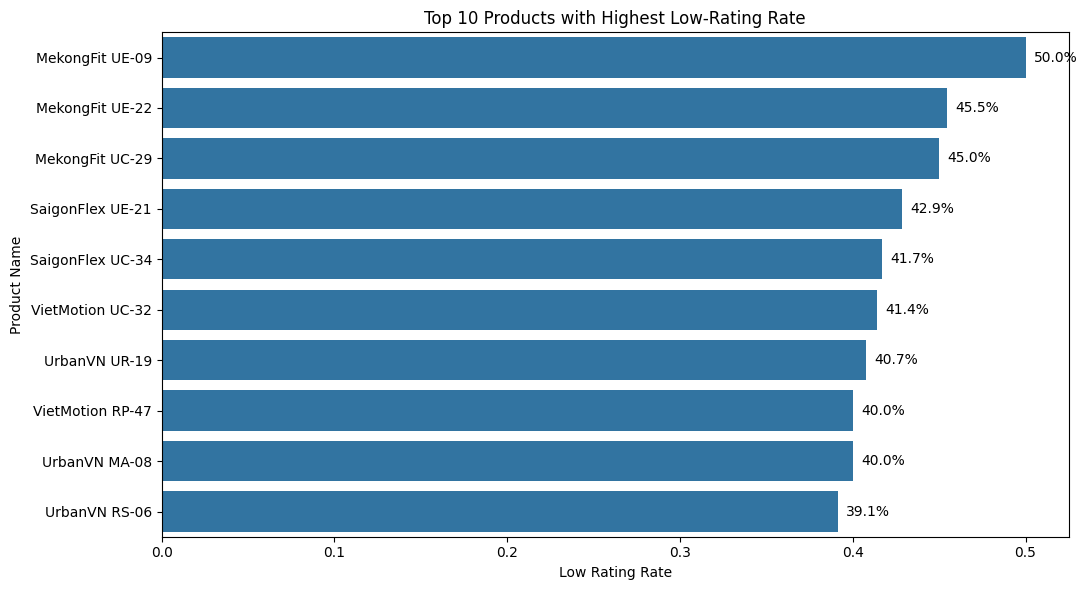

In [22]:
top_risky_products = product_rating[
    product_rating["num_reviews"] >= 20
].copy()

top_risky_products = top_risky_products.sort_values(
    ["low_rating_rate", "num_reviews"],
    ascending=[False, False]
).head(10)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_risky_products,
    x="low_rating_rate",
    y="product_name"
)

plt.title("Top 10 Products with Highest Low-Rating Rate")
plt.xlabel("Low Rating Rate")
plt.ylabel("Product Name")

for i, value in enumerate(top_risky_products["low_rating_rate"]):
    plt.text(
        value + 0.005,
        i,
        f"{value*100:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [23]:
top_priority_products = product_rating[
    product_rating["priority_group"] != "Monitor"
].copy()

top_priority_products = top_priority_products.sort_values(
    ["avg_rating", "low_rating_rate", "num_reviews"],
    ascending=[True, False, False]
)

top_priority_products_display = top_priority_products[[
    "product_id",
    "product_name",
    "category",
    "segment",
    "avg_rating",
    "low_rating_rate",
    "num_reviews",
    "avg_delivery_days",
    "priority_group"
]].head(15)

top_priority_products_display["avg_rating"] = top_priority_products_display["avg_rating"].round(2)
top_priority_products_display["low_rating_rate"] = (top_priority_products_display["low_rating_rate"] * 100).round(1)
top_priority_products_display["avg_delivery_days"] = top_priority_products_display["avg_delivery_days"].round(2)

top_priority_products_display

,product_id,product_name,category,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,priority_group
275,1227.0,MekongFit UC-29,Streetwear,Everyday,3.50,45.0,20,6.15,"Logistics issue: Low rating, slow delivery"
426,2064.0,UrbanVN UE-24,Streetwear,Performance,3.56,38.0,71,6.20,"Logistics issue: Low rating, slow delivery"
472,2250.0,VietMotion RP-47,Outdoor,Activewear,3.61,40.0,80,6.00,"Urgent: Low rating, high reviews, slow delivery"
456,2212.0,VietMotion RP-09,Outdoor,Activewear,3.62,38.2,55,6.02,"Logistics issue: Low rating, slow delivery"
87,533.0,SaigonFlex UE-21,Streetwear,Performance,3.62,42.9,21,6.71,"Logistics issue: Low rating, slow delivery"
192,967.0,HanoiStreet UC-30,Streetwear,Everyday,3.64,35.7,70,6.11,"Logistics issue: Low rating, slow delivery"
393,1963.0,UrbanVN RP-38,Outdoor,Activewear,3.66,34.5,29,6.21,"Logistics issue: Low rating, slow delivery"
92,566.0,SaigonFlex UC-31,Streetwear,Everyday,3.67,36.7,30,6.27,"Logistics issue: Low rating, slow delivery"
125,682.0,SaigonFlex UC-47,Streetwear,Everyday,3.67,33.3,27,6.22,"Logistics issue: Low rating, slow delivery"
467,2235.0,VietMotion RP-32,Outdoor,Activewear,3.69,36.9,84,5.71,"Product issue: Low rating, high reviews"


In [24]:
product_review_priority = product_rating.copy()

product_review_priority["low_rating_count"] = (
    product_review_priority["low_rating_rate"] * product_review_priority["num_reviews"]
).round(0)

# Chỉ xét sản phẩm có đủ review để tránh sample nhỏ
min_reviews = 30

priority_table = product_review_priority[
    product_review_priority["num_reviews"] >= min_reviews
].copy()

priority_table = priority_table.sort_values(
    ["low_rating_rate", "low_rating_count", "num_reviews"],
    ascending=[False, False, False]
)

priority_table_display = priority_table[[
    "product_id",
    "product_name",
    "category",
    "segment",
    "avg_rating",
    "num_reviews",
    "low_rating_rate",
    "low_rating_count",
    "avg_delivery_days"
]].head(15)

priority_table_display["avg_rating"] = priority_table_display["avg_rating"].round(2)
priority_table_display["low_rating_rate"] = (
    priority_table_display["low_rating_rate"] * 100
).round(1)
priority_table_display["avg_delivery_days"] = priority_table_display["avg_delivery_days"].round(2)

priority_table_display

,product_id,product_name,category,segment,avg_rating,num_reviews,low_rating_rate,low_rating_count,avg_delivery_days
259,1173.0,MekongFit UE-09,Streetwear,Performance,3.47,34,50.0,17.0,5.82
472,2250.0,VietMotion RP-47,Outdoor,Activewear,3.61,80,40.0,32.0,6.00
456,2212.0,VietMotion RP-09,Outdoor,Activewear,3.62,55,38.2,21.0,6.02
392,1962.0,UrbanVN RP-37,Outdoor,Activewear,3.76,42,38.1,16.0,6.29
426,2064.0,UrbanVN UE-24,Streetwear,Performance,3.56,71,38.0,27.0,6.20
102,606.0,SaigonFlex UC-71,Streetwear,Everyday,3.77,79,38.0,30.0,5.86
455,2205.0,VietMotion RP-02,Outdoor,Activewear,3.76,66,37.9,25.0,6.08
467,2235.0,VietMotion RP-32,Outdoor,Activewear,3.69,84,36.9,31.0,5.71
92,566.0,SaigonFlex UC-31,Streetwear,Everyday,3.67,30,36.7,11.0,6.27
270,1203.0,MekongFit UC-05,Streetwear,Everyday,3.70,30,36.7,11.0,5.93


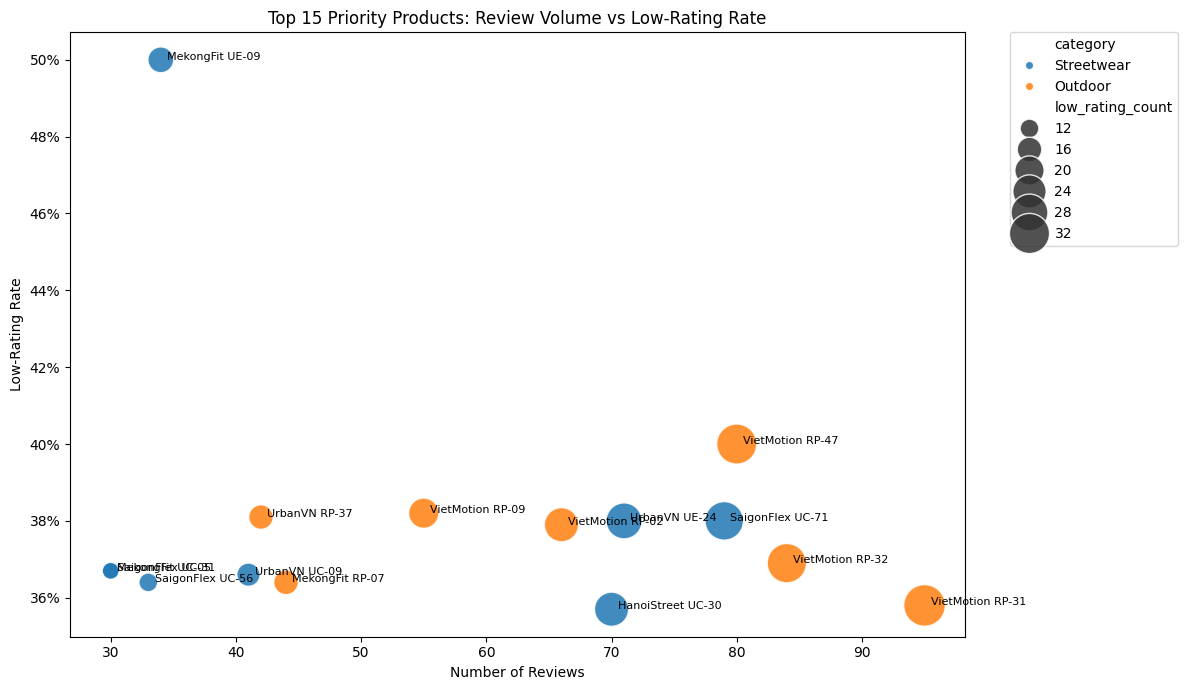

In [25]:
# =========================
# MATRIX CHỈ CHO TOP 15 PRIORITY PRODUCTS
# =========================

top15_df = priority_table_display.copy()

# Nếu low_rating_rate đang là phần trăm như 46.3 thì đưa về 0-1 để plot
if top15_df["low_rating_rate"].max() > 1:
    top15_df["low_rating_rate_plot"] = top15_df["low_rating_rate"] / 100
else:
    top15_df["low_rating_rate_plot"] = top15_df["low_rating_rate"]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=top15_df,
    x="num_reviews",
    y="low_rating_rate_plot",
    size="low_rating_count",
    hue="category",
    sizes=(150, 900),
    alpha=0.85
)

for _, row in top15_df.iterrows():
    plt.text(
        row["num_reviews"] + 0.5,
        row["low_rating_rate_plot"],
        row["product_name"],
        fontsize=8
    )

plt.title("Top 15 Priority Products: Review Volume vs Low-Rating Rate")
plt.xlabel("Number of Reviews")
plt.ylabel("Low-Rating Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%")
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [26]:
priority_products = product_rating.sort_values(
    ["priority_group", "avg_rating", "num_reviews"],
    ascending=[True, True, False]
)

priority_products.head(20)

,product_id,product_name,category,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,priority_group
275,1227.0,MekongFit UC-29,Streetwear,Everyday,3.500000,0.450000,20,6.150000,3803.996186,"Logistics issue: Low rating, slow delivery"
426,2064.0,UrbanVN UE-24,Streetwear,Performance,3.563380,0.380282,71,6.197183,6479.721272,"Logistics issue: Low rating, slow delivery"
456,2212.0,VietMotion RP-09,Outdoor,Activewear,3.618182,0.381818,55,6.018182,1075.947169,"Logistics issue: Low rating, slow delivery"
87,533.0,SaigonFlex UE-21,Streetwear,Performance,3.619048,0.428571,21,6.714286,6086.914024,"Logistics issue: Low rating, slow delivery"
192,967.0,HanoiStreet UC-30,Streetwear,Everyday,3.642857,0.357143,70,6.114286,8161.481465,"Logistics issue: Low rating, slow delivery"
393,1963.0,UrbanVN RP-38,Outdoor,Activewear,3.655172,0.344828,29,6.206897,1794.870000,"Logistics issue: Low rating, slow delivery"
92,566.0,SaigonFlex UC-31,Streetwear,Everyday,3.666667,0.366667,30,6.266667,11783.942843,"Logistics issue: Low rating, slow delivery"
125,682.0,SaigonFlex UC-47,Streetwear,Everyday,3.666667,0.333333,27,6.222222,11641.827273,"Logistics issue: Low rating, slow delivery"
72,488.0,SaigonFlex UM-93,Streetwear,Balanced,3.714286,0.357143,28,6.178571,12855.294845,"Logistics issue: Low rating, slow delivery"
454,2204.0,VietMotion RP-01,Outdoor,Activewear,3.716667,0.350000,60,6.250000,1771.100769,"Logistics issue: Low rating, slow delivery"


In [27]:
overall_avg_rating = df_7["rating"].mean()
overall_low_rating_rate = df_7["low_rating"].mean() * 100

worst_category = category_rating.sort_values("avg_rating").iloc[0]
highest_low_category = category_rating.sort_values("low_rating_rate", ascending=False).iloc[0]

worst_segment = segment_rating.sort_values("avg_rating").iloc[0]

worst_delivery_speed = delivery_speed_perf.sort_values("avg_rating").iloc[0]
highest_low_delivery_speed = delivery_speed_perf.sort_values("low_rating_rate", ascending=False).iloc[0]

top_priority_product = product_rating[
    product_rating["priority_group"] != "Monitor"
].sort_values(["avg_rating", "num_reviews"], ascending=[True, False]).head(1)

print("OVERALL SATISFACTION")
print(f"- Average rating: {overall_avg_rating:.2f}/5")
print(f"- Low rating rate (≤3 stars): {overall_low_rating_rate:.2f}%")

print("\nDELIVERY IMPACT")
print(f"- Worst delivery speed group: {worst_delivery_speed['delivery_speed']} with average rating {worst_delivery_speed['avg_rating']:.2f}")
print(f"- Highest low-rating delivery group: {highest_low_delivery_speed['delivery_speed']} with low rating rate {highest_low_delivery_speed['low_rating_rate']*100:.2f}%")

print("\nCATEGORY IMPACT")
print(f"- Worst category by average rating: {worst_category['category']} with average rating {worst_category['avg_rating']:.2f}")
print(f"- Highest low-rating category: {highest_low_category['category']} with low rating rate {highest_low_category['low_rating_rate']*100:.2f}%")

print("\nSEGMENT IMPACT")
print(f"- Worst segment by average rating: {worst_segment['segment']} with average rating {worst_segment['avg_rating']:.2f}")

print("\nPRIORITY PRODUCT")
if len(top_priority_product) > 0:
    p = top_priority_product.iloc[0]
    print(f"- Product to prioritize: {p['product_name']} | avg rating {p['avg_rating']:.2f}, reviews {p['num_reviews']}, avg delivery {p['avg_delivery_days']:.2f} days")
else:
    print("- No urgent product found under current thresholds.")

OVERALL SATISFACTION
- Average rating: 3.94/5
- Low rating rate (≤3 stars): 27.74%

DELIVERY IMPACT
- Worst delivery speed group: Slow: 6-7 days with average rating 3.92
- Highest low-rating delivery group: Slow: 6-7 days with low rating rate 28.61%

CATEGORY IMPACT
- Worst category by average rating: Outdoor with average rating 3.92
- Highest low-rating category: Outdoor with low rating rate 28.53%

SEGMENT IMPACT
- Worst segment by average rating: Performance with average rating 3.90

PRIORITY PRODUCT
- Product to prioritize: MekongFit UC-29 | avg rating 3.50, reviews 20, avg delivery 6.15 days
